# experiments/01: Encoder Comparison — Sum vs Attentive Message Passing

**Experimental question:** Does attention-weighted message passing outperform plain sum aggregation for encoding CRNs?

**Controlled variables:** same CRN (birth-death), same training mode (NLL / teacher forcing), same architecture, same data.

**Structure:**
1. Configuration
2. Training Data
3. Train — Sum Encoder
4. Train — Attentive Encoder
5. Training Curves
6. Learned Dynamics
7. Trajectory Quality
8. Residual Analysis
9. Summary Metrics

In [10]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from _shared.plotting import setup_style, plot_trajectory_ensemble

setup_style()

import time
import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(42)
np.random.seed(42)

## 1. Configuration

Both runs share the same CRN, SDE config, training config, and data. The only difference is `use_attention` in `EncoderConfig`.

In [11]:
from crn_surrogate.configs.model_config import EncoderConfig, ModelConfig, SDEConfig
from crn_surrogate.configs.training_config import SchedulerType, TrainingConfig, TrainingMode
from crn_surrogate.data.generation.reference_crns import birth_death
from crn_surrogate.evaluation.analytical import birth_death_analytical
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

crn        = birth_death(k_birth=2.0, k_death=0.5)   # stationary mean = var = 4
crn_repr   = crn_to_tensor_repr(crn)
analytical = birth_death_analytical(k_birth=2.0, k_death=0.5)

sde_config         = SDEConfig.from_crn(crn, d_model=32, d_hidden=64, clip_state=True)
encoder_config_sum = EncoderConfig(d_model=32, n_layers=2, use_attention=False)
encoder_config_att = EncoderConfig(d_model=32, n_layers=2, use_attention=True)

train_config = TrainingConfig(
    lr=3e-3,
    max_epochs=30,
    batch_size=4,
    n_sde_samples=8,
    n_ssa_samples=16,
    dt=0.2,
    val_every=5,
    grad_clip_norm=1.0,
    scheduler_type=SchedulerType.REDUCE_ON_PLATEAU,
    training_mode=TrainingMode.TEACHER_FORCING,
    use_wandb=False,
)

print(f"CRN:            {crn}")
print(f"SDE:            {sde_config}")
print(f"Encoder (sum):  {encoder_config_sum}")
print(f"Encoder (att):  {encoder_config_att}")
print(f"Training:       {train_config}")
print(f"Stationary:     mean={analytical['stationary_mean']:.1f}  var={analytical['stationary_var']:.1f}")

CRN:            CRN(n_species=1, n_reactions=2, species=('A',))
SDE:            SDEConfig(d_model=32, d_hidden=64, n_noise_channels=2, n_hidden_layers=2, clip_state=True)
Encoder (sum):  EncoderConfig(d_model=32, n_layers=2, n_propensity_types=7, max_propensity_params=8)
Encoder (att):  EncoderConfig(d_model=32, n_layers=2, n_propensity_types=7, max_propensity_params=8)
Training:       TrainingConfig(lr=0.003, max_epochs=30, batch_size=4, dt=0.2, n_ssa_samples=16, scheduler=reduce_on_plateau, training_mode=teacher_forcing, use_wandb=False)
Stationary:     mean=4.0  var=4.0


## 2. Training Data

Train: 60 items × 16 SSA = 960 trajectories
Val:   20 items × 16 SSA = 320 trajectories


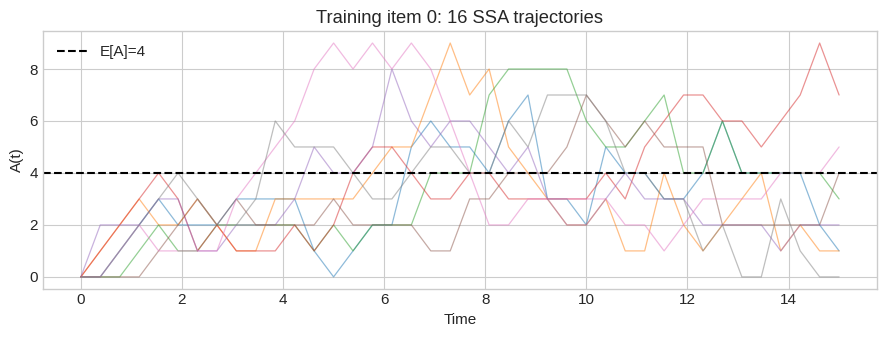

In [12]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem
from crn_surrogate.simulation import GillespieSSA, Trajectory

T_MAX   = 15.0
N_GRID  = 40
N_WORKERS = 8
M       = train_config.n_ssa_samples
time_grid  = torch.linspace(0.0, T_MAX, N_GRID)
init_state = torch.tensor([0.0])
ssa        = GillespieSSA()


def make_dataset(n: int) -> CRNTrajectoryDataset:
    items = []
    for _ in range(n):
        trajs = []
        # for _ in range(M):
        trajectories = ssa.simulate_batch(
            stoichiometry=crn.stoichiometry_matrix,
            propensity_fn=crn.evaluate_propensities,
            initial_state=init_state.clone(),
            t_max=T_MAX,
            n_trajectories=M,
            n_workers=N_WORKERS,
        )
        trajectories_tensor = Trajectory.stack_on_grid(trajectories, time_grid)
            # trajs.append(interpolate_to_grid(result.times, result.states, time_grid))
        items.append(TrajectoryItem(
            crn_repr=crn_repr,
            initial_state=init_state.clone(),
            trajectories=trajectories_tensor,
            times=time_grid,
        ))
    return CRNTrajectoryDataset(items)


train_dataset = make_dataset(60)
val_dataset   = make_dataset(20)
print(f"Train: {len(train_dataset)} items \u00d7 {M} SSA = {len(train_dataset) * M} trajectories")
print(f"Val:   {len(val_dataset)} items \u00d7 {M} SSA = {len(val_dataset) * M} trajectories")

fig, ax = plt.subplots(figsize=(9, 3.5))
item = train_dataset[0]
for m in range(min(8, M)):
    ax.plot(time_grid.numpy(), item.trajectories[m, :, 0].numpy(), alpha=0.5, lw=0.9)
ax.axhline(analytical["stationary_mean"], color="black", linestyle="--", lw=1.5,
           label=f"E[A]={analytical['stationary_mean']:.0f}")
ax.set_xlabel("Time")
ax.set_ylabel("A(t)")
ax.set_title(f"Training item 0: {M} SSA trajectories")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Train — Sum Encoder

In [ ]:
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE
from crn_surrogate.training.trainer import Trainer

encoder_sum   = BipartiteGNNEncoder(encoder_config_sum)
sde_sum       = CRNNeuralSDE(sde_config, n_species=1)
model_cfg_sum = ModelConfig(encoder=encoder_config_sum, sde=sde_config)

t0 = time.perf_counter()
result_sum = Trainer(encoder_sum, sde_sum, model_cfg_sum, train_config).train(train_dataset, val_dataset)
elapsed_sum = time.perf_counter() - t0
print(f"\nSum encoder: {elapsed_sum:.1f}s total  ({elapsed_sum / train_config.max_epochs:.2f}s/epoch)")

## 4. Train — Attentive Encoder

In [13]:
encoder_att   = BipartiteGNNEncoder(encoder_config_att)
sde_att       = CRNNeuralSDE(sde_config, n_species=1)
model_cfg_att = ModelConfig(encoder=encoder_config_att, sde=sde_config)

t0 = time.perf_counter()
result_att = Trainer(encoder_att, sde_att, model_cfg_att, train_config).train(train_dataset, val_dataset)
elapsed_att = time.perf_counter() - t0
print(f"\nAttentive encoder: {elapsed_att:.1f}s total  ({elapsed_att / train_config.max_epochs:.2f}s/epoch)")

Epoch    1 | train=-0.6026 | grad=0.466


Epoch    2 | train=-0.6552 | grad=0.291


Epoch    3 | train=-0.6589 | grad=0.179


Epoch    4 | train=-0.6582 | grad=0.188


Epoch    5 | train=-0.6588 | val_nll=-0.6429 | grad=0.173


...

Epoch   26 | train=-0.6597 | grad=0.148


Epoch   27 | train=-0.6610 | grad=0.099


Epoch   28 | train=-0.6603 | grad=0.114


Epoch   29 | train=-0.6600 | grad=0.127


Epoch   30 | train=-0.6607 | val_nll=-0.6465 | grad=0.117

Attentive encoder: 93.3s total  (3.11s/epoch)


## 5. Training Curves

/tmp/ipykernel_1912922/2002920464.py:17: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale(yscale)


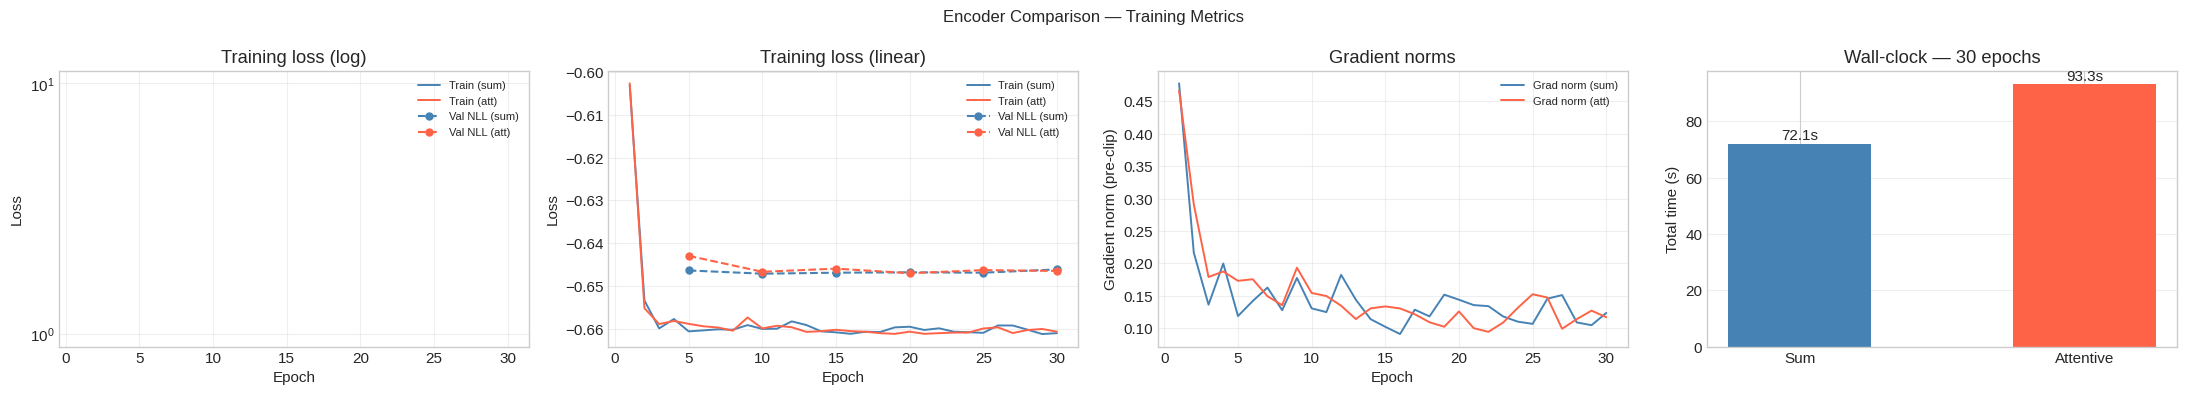

In [14]:
C_SUM = "steelblue"
C_ATT = "tomato"
epochs = range(1, train_config.max_epochs + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, yscale in zip(axes[:2], ["log", "linear"]):
    ax.plot(epochs, result_sum.train_losses, color=C_SUM, lw=1.4, label="Train (sum)")
    ax.plot(epochs, result_att.train_losses, color=C_ATT, lw=1.4, label="Train (att)")
    if result_sum.val_nll_losses:
        ax.plot(result_sum.val_epochs, result_sum.val_nll_losses,
                "o--", color=C_SUM, markersize=5, label="Val NLL (sum)")
        ax.plot(result_att.val_epochs, result_att.val_nll_losses,
                "o--", color=C_ATT, markersize=5, label="Val NLL (att)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale(yscale)
    ax.set_title(f"Training loss ({yscale})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax = axes[2]
if result_sum.grad_norms:
    ax.plot(epochs, result_sum.grad_norms, color=C_SUM, lw=1.4, label="Grad norm (sum)")
    ax.plot(epochs, result_att.grad_norms, color=C_ATT, lw=1.4, label="Grad norm (att)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gradient norm (pre-clip)")
ax.set_title("Gradient norms")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[3]
bars = ax.bar(["Sum", "Attentive"], [elapsed_sum, elapsed_att], color=[C_SUM, C_ATT], width=0.5)
for bar, val in zip(bars, [elapsed_sum, elapsed_att]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}s", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Total time (s)")
ax.set_title(f"Wall-clock \u2014 {train_config.max_epochs} epochs")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Encoder Comparison \u2014 Training Metrics", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Learned Dynamics

The "money plot": did the model learn the right drift and diffusion functions?

- **Drift** should be linear and cross zero at x = k_birth/k_death = 4.
- **Diffusion** should increase with x (noise grows with population).

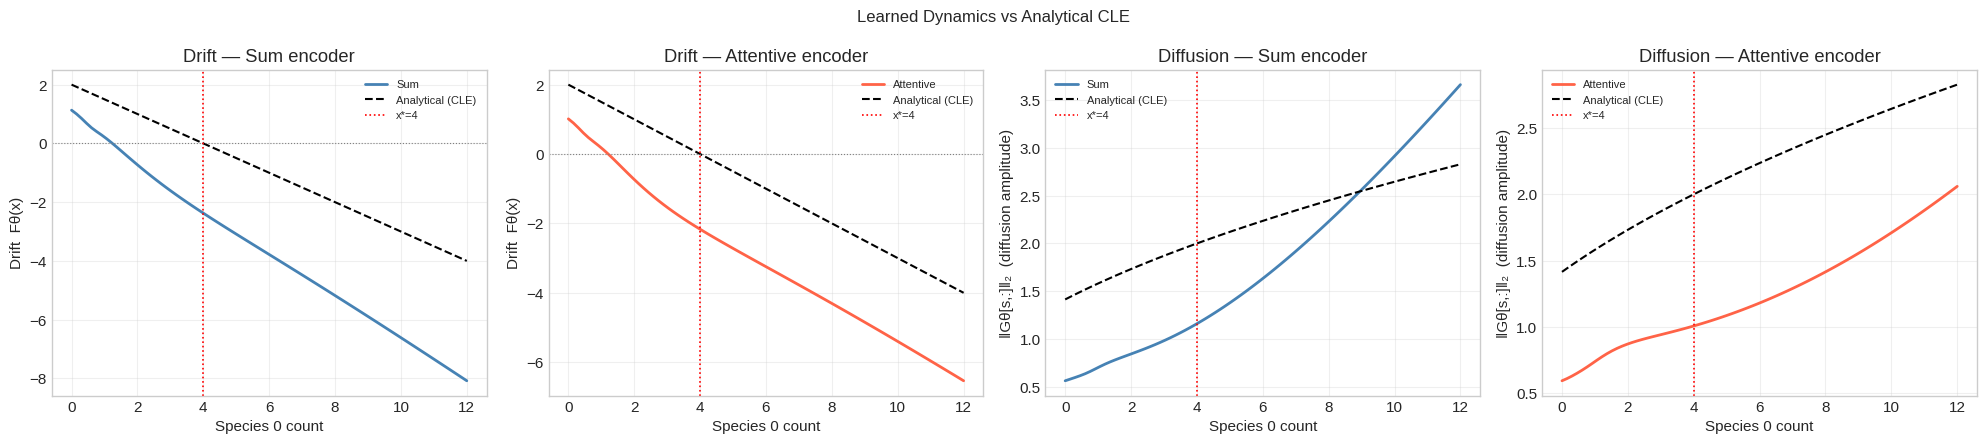

In [15]:
from crn_surrogate.evaluation import DynamicsVisualizer

state_range = torch.linspace(0.0, 12.0, 80)

viz_sum = DynamicsVisualizer(encoder_sum, sde_sum, crn_repr, init_state)
viz_att = DynamicsVisualizer(encoder_att, sde_att, crn_repr, init_state)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

viz_sum.plot_drift(state_range, analytical_drift_fn=analytical["drift"],
                   label="Sum", color=C_SUM, ax=axes[0])
axes[0].set_title("Drift \u2014 Sum encoder")

viz_att.plot_drift(state_range, analytical_drift_fn=analytical["drift"],
                   label="Attentive", color=C_ATT, ax=axes[1])
axes[1].set_title("Drift \u2014 Attentive encoder")

viz_sum.plot_diffusion(state_range, analytical_diffusion_fn=analytical["diffusion"],
                       label="Sum", color=C_SUM, ax=axes[2])
axes[2].set_title("Diffusion \u2014 Sum encoder")

viz_att.plot_diffusion(state_range, analytical_diffusion_fn=analytical["diffusion"],
                       label="Attentive", color=C_ATT, ax=axes[3])
axes[3].set_title("Diffusion \u2014 Attentive encoder")

for ax in axes:
    ax.axvline(analytical["stationary_mean"], color="red", linestyle=":", lw=1.2,
               label=f"x*={analytical['stationary_mean']:.0f}")
    ax.legend(fontsize=8)

plt.suptitle("Learned Dynamics vs Analytical CLE", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Trajectory Quality

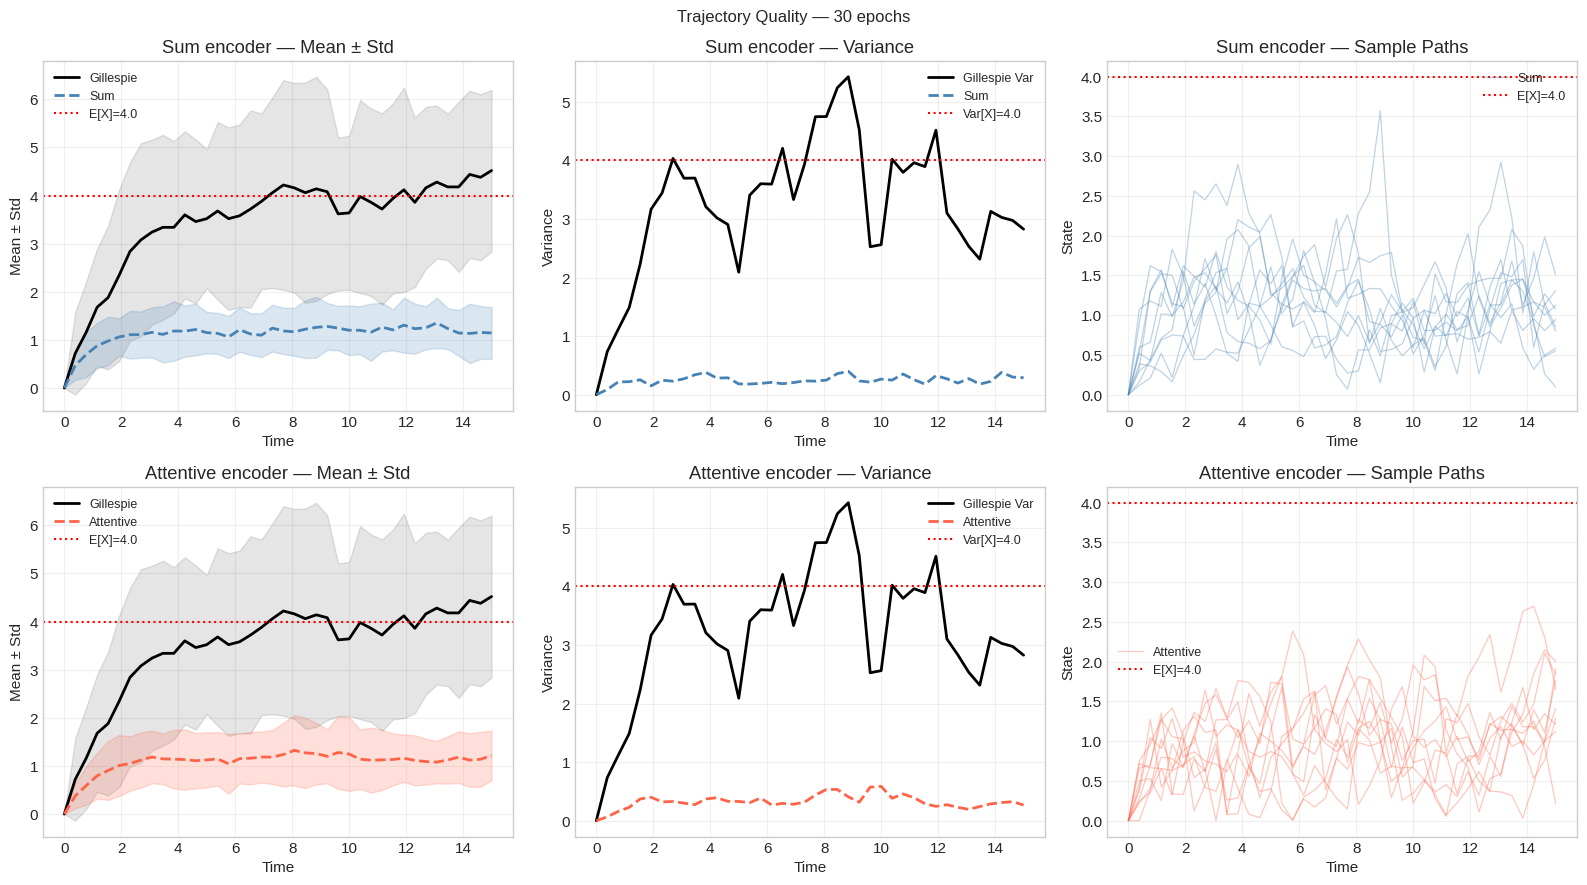

In [16]:
from crn_surrogate.evaluation import ModelEvaluator, TrajectoryComparator

eval_times = torch.linspace(0.0, T_MAX, N_GRID)
K_EVAL, M_EVAL = 50, 50

ssa_trajs = Trajectory.stack_on_grid(
    ssa.simulate_batch(
        stoichiometry=crn.stoichiometry_matrix,
        propensity_fn=crn.evaluate_propensities,
        initial_state=init_state.clone(),
        t_max=T_MAX,
        n_trajectories=M_EVAL,
        n_workers=N_WORKERS,
    ),
    eval_times,
)  # (M_EVAL, N_GRID, 1)

evaluator_sum = ModelEvaluator(encoder_sum, sde_sum, sde_config)
evaluator_att = ModelEvaluator(encoder_att, sde_att, sde_config)

sde_trajs_sum = evaluator_sum.rollout(crn_repr, init_state, eval_times, dt=0.1, n_rollouts=K_EVAL)
sde_trajs_att = evaluator_att.rollout(crn_repr, init_state, eval_times, dt=0.1, n_rollouts=K_EVAL)

comp_sum = TrajectoryComparator(sde_trajs_sum, ssa_trajs, eval_times,
                                analytical_mean=analytical["stationary_mean"],
                                analytical_var=analytical["stationary_var"])
comp_att = TrajectoryComparator(sde_trajs_att, ssa_trajs, eval_times,
                                analytical_mean=analytical["stationary_mean"],
                                analytical_var=analytical["stationary_var"])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

kw_sum = {"sde_label": "Sum", "sde_color": C_SUM}
kw_att = {"sde_label": "Attentive", "sde_color": C_ATT}

comp_sum.plot_mean_std(**kw_sum, ax=axes[0, 0])
comp_sum.plot_variance(**kw_sum, ax=axes[0, 1])
comp_sum.plot_sample_paths(**kw_sum, ax=axes[0, 2])

comp_att.plot_mean_std(**kw_att, ax=axes[1, 0])
comp_att.plot_variance(**kw_att, ax=axes[1, 1])
comp_att.plot_sample_paths(**kw_att, ax=axes[1, 2])

for row, label in enumerate(["Sum encoder", "Attentive encoder"]):
    axes[row, 0].set_title(f"{label} — Mean ± Std")
    axes[row, 1].set_title(f"{label} — Variance")
    axes[row, 2].set_title(f"{label} — Sample Paths")

plt.suptitle(f"Trajectory Quality — {train_config.max_epochs} epochs", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Residual Analysis

Standardized residuals $z_s = (y_{t+1} - \mu_s) / \sigma_s$ should be approximately $\mathcal{N}(0,1)$ if the Gaussian SDE assumption is valid. The histogram and QQ plot reveal systematic model errors that trajectory plots cannot capture.

In [ ]:
from crn_surrogate.evaluation import ResidualAnalyzer

analyzer_sum = ResidualAnalyzer(encoder_sum, sde_sum, crn_repr)
analyzer_att = ResidualAnalyzer(encoder_att, sde_att, crn_repr)

report_sum = analyzer_sum.compute_residuals(ssa_trajs, eval_times, dt=0.2, initial_state=init_state)
report_att = analyzer_att.compute_residuals(ssa_trajs, eval_times, dt=0.2, initial_state=init_state)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

analyzer_sum.plot_histogram(report_sum, label="Sum", color=C_SUM, ax=axes[0, 0])
analyzer_sum.plot_qq(report_sum, label="Sum", color=C_SUM, ax=axes[0, 1])
analyzer_att.plot_histogram(report_att, label="Attentive", color=C_ATT, ax=axes[1, 0])
analyzer_att.plot_qq(report_att, label="Attentive", color=C_ATT, ax=axes[1, 1])

for row, label in enumerate(["Sum encoder", "Attentive encoder"]):
    axes[row, 0].set_title(f"{label} \u2014 Residual Histogram")
    axes[row, 1].set_title(f"{label} \u2014 QQ Plot")

plt.suptitle("Residual Analysis \u2014 Gaussian assumption check", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Summary Metrics

In [ ]:
true_mean = analytical["stationary_mean"]
true_var  = analytical["stationary_var"]

print(f"{'Metric':<28} {'Sum':>12} {'Attentive':>12}  {'Better':>10}")
print("-" * 66)
for key in ["mean_mse", "var_mse", "final_mean", "final_var", "mean_sde_std"]:
    v_sum = comp_sum.metrics()[key]
    v_att = comp_att.metrics()[key]
    if key in ("mean_mse", "var_mse"):
        better = "Att" if v_att < v_sum else "Sum"
    elif key == "final_mean":
        better = "Att" if abs(v_att - true_mean) < abs(v_sum - true_mean) else "Sum"
    else:
        better = ""
    print(f"{key:<28} {v_sum:>12.4f} {v_att:>12.4f}  {better:>10}")

print()
print(f"Residual mean  (\u21920):  Sum={report_sum.mean[0].item():.3f}  Att={report_att.mean[0].item():.3f}")
print(f"Residual std   (\u21921):  Sum={report_sum.std[0].item():.3f}   Att={report_att.std[0].item():.3f}")
print(f"Residual kurt  (\u21923):  Sum={report_sum.kurtosis[0].item():.2f}  Att={report_att.kurtosis[0].item():.2f}")
print()
if result_sum.val_nll_losses:
    print(f"Final val NLL:        Sum={result_sum.val_nll_losses[-1]:.4f}  Att={result_att.val_nll_losses[-1]:.4f}")